# Scattering by $N$ sound-hard spheres at **arbitrary centers** in $\mathbb{R}^3$

This notebook extends `Nspheres_sound_hard.ipynb` from spheres on the $z$-axis to
spheres with genuinely three-dimensional centers $C_i\in\mathbb{R}^3$.  Off the
axis the scattered field of a sphere is no longer axisymmetric about the global
$z$-axis, so each trace must be expanded in the **full** spherical-harmonic basis
$Y_n^m$ ($n=0..N_b-1$, $m=-n..n$): $N_b^2$ unknowns per sphere, ordered exactly as
`ComputeSphericalHarmonics`.

Total-field formulation (unchanged from the axisymmetric case):

$$u(x)=u^{inc}(x)+\sum_i D_i[u_i](x),\qquad
\Big[a_i^2\,\mathrm{diag}(\lambda_n(a_i))\,\delta_{ij}-(1-\delta_{ij})B_{ij}\Big]c=b,$$

with $\lambda_n(a)=-i(ka)^2 j_n(ka)\,{h_n^{(1)}}'(ka)$ ($m$-independent),
$B_{ij}=\langle Y_p^q,\,D_j[Y_n^m]\rangle_{\partial B_i}$ the Galerkin coupling
block assembled by the **Carvalho–Khatri–Kim close-evaluation quadrature**
(rotated grid + plane-wave subtraction), and $b^i$ the $Y_n^m$-projection of the
incident plane-wave trace (times $a_i^2$).

The only change versus the axisymmetric module is that the layer density is the
full $Y_n^m$ evaluated at the **rotated** grid angles rather than the
axisymmetric $\tilde P_n=Y_n^0$.  For spheres the ground truth is the multipole
identity
$$D[Y_n^m\text{ about }C](x)=i k^2 a^2\,j_n'(ka)\,h_n^{(1)}(k|x-C|)\,Y_n^m(\theta_x,\phi_x),$$
$(\theta_x,\phi_x)$ the spherical angles of $x-C$ — verified numerically below.

Everything lives in the companion module `multisphere_bie.py`.

**Tolerances.** Except for the two close-gap checks, every validation compares
against an *analytic* quantity (exact multipole columns, Mie coefficients, or a
symmetry that holds exactly), so the achieved errors sit at the linear-solve /
harmonic-evaluation floor ($\sim10^{-13}$) and the asserted thresholds are set
accordingly.  The two quadrature checks (columns $10^{-6}$ off the surface, and
the gap-$0.05$ coupling blocks) are limited by the close-evaluation quadrature
floor at the chosen order; their thresholds ($10^{-6}$, $10^{-3}$) are the
documented quadrature tolerances, matching the style of the axisymmetric
notebook.

In [1]:
import time
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

from offdiag_bie import (SphereQuadrature, coupling_block, ptilde,
                         dlp_column_exact)
from essentials_bie import ComputeSphericalHarmonics
import multisphere_bie as ms

np.set_printoptions(precision=3, suppress=False)
t_start = time.time()
k = 2.0                      # wavenumber used throughout

## Validation 1 — double-layer columns $D[Y_n^m]$

First the multipole identity itself is checked: the exact columns
`ms.dlp_columns_ynm(..., method='exact')` are compared against a naive
product-Gauss quadrature of $D[Y_n^m]$ at a **well-separated** target, for all
$m$ (not just $m=0$).  Then the close-evaluation columns (`method='subtract'`)
are compared to the exact ones at targets in general position — both
well-separated and only $10^{-6}$ off the source sphere, where plain quadrature
(`method='naive'`) fails at $O(1)$.

In [2]:
Nb, a, C = 6, 0.9, np.array([0.3, -0.2, 0.5])
quad = SphereQuadrature(24)

# (a) exact multipole identity vs naive quadrature at a well-separated target,
#     all m.  Build the naive DLP columns directly here as an independent check.
xw = C + np.array([2.0, 1.5, -1.0])
from essentials_bie import GaussLegendre
mu, _, MU, PHI, WTS, _ = GaussLegendre(40)
thg = np.arccos(MU); phg = PHI
nu = np.column_stack([np.sin(thg)*np.cos(phg), np.sin(thg)*np.sin(phg), np.cos(thg)])
yg = C + a*nu
Ysrc, nvec, mvec = ComputeSphericalHarmonics(Nb, thg, phg)
yd = xw - yg; r = np.linalg.norm(yd, axis=1); nu_yd = np.sum(nu*yd, axis=1)
Gk = np.exp(1j*k*r)/(4*np.pi*r)
Dk = (1/r - 1j*k)*nu_yd/r*Gk
naive_cols = (Dk*WTS*a**2) @ Ysrc
exact_cols = ms.dlp_columns_ynm(Nb, k, a, C, xw, method='exact')
err_identity = np.max(np.abs(naive_cols - exact_cols))
print(f"[1a] exact multipole identity vs independent naive quadrature (all m):"
      f"  max abs err = {err_identity:.3e}")
assert err_identity < 1e-8

# (b) subtract vs exact at targets in general position
rng = np.random.default_rng(0)
dirs = rng.standard_normal((6, 3)); dirs /= np.linalg.norm(dirs, axis=1)[:, None]
far  = C + (a + rng.uniform(0.4, 1.8, 6)[:, None]) * dirs
near = C + (a + 1e-6) * dirs
ex_far  = ms.dlp_columns_ynm(Nb, k, a, C, far,  method='exact')
su_far  = ms.dlp_columns_ynm(Nb, k, a, C, far,  quad, method='subtract')
ex_near = ms.dlp_columns_ynm(Nb, k, a, C, near, method='exact')
su_near = ms.dlp_columns_ynm(Nb, k, a, C, near, quad, method='subtract')
na_near = ms.dlp_columns_ynm(Nb, k, a, C, near, quad, method='naive')
e_far  = np.max(np.abs(su_far  - ex_far))
e_near = np.max(np.abs(su_near - ex_near))
e_naive = np.max(np.abs(na_near - ex_near))
print(f"[1b] subtract vs exact, well separated       : max abs err = {e_far:.3e}")
print(f"[1b] subtract vs exact, 1e-6 off the surface  : max abs err = {e_near:.3e}")
print(f"[1b] naive    vs exact, 1e-6 off the surface  : max abs err = {e_naive:.3e}"
      f"   (naive fails)")
assert e_far  < 1e-8
assert e_near < 1e-6
assert e_naive > 1e-2

[1a] exact multipole identity vs independent naive quadrature (all m):  max abs err = 1.769e-16
[1b] subtract vs exact, well separated       : max abs err = 1.294e-11
[1b] subtract vs exact, 1e-6 off the surface  : max abs err = 1.239e-10
[1b] naive    vs exact, 1e-6 off the surface  : max abs err = 2.877e-01   (naive fails)


## Validation 2 — single sphere at an **off-axis** center vs exact Mie

A single hard sphere centered at $C=(0.4,-0.3,0.2)$ is illuminated by
$u^{inc}=e^{ikz}$.  Because the incidence is still $z$-directed, the trace is
axisymmetric **about the sphere's own center**: only the $m=0$ coefficients are
non-zero, and they must equal the exact Mie coefficients
$e^{ikC_z} i^n\sqrt{4\pi(2n+1)}\,\dfrac{i/(ka)^2}{{h_n^{(1)}}'(ka)}$ (with the
$e^{ikC_z}$ phase from the off-axis center).  All $m\neq0$ coefficients must
vanish.

In [3]:
def mie_trace_coeffs(N, k, a, z):
    n = np.arange(N)
    dhn = sp.spherical_jn(n, k*a, derivative=True) \
        + 1j*sp.spherical_yn(n, k*a, derivative=True)
    return np.exp(1j*k*z)*(1j)**n*np.sqrt(4*np.pi*(2*n+1))*(1j/(k*a)**2)/dhn

Nb2, a2, C2 = 12, 1.0, np.array([0.4, -0.3, 0.2])
c_single = ms.solve(Nb2, k, [a2], C2[None, :], quad, method='exact')[0]
nvec2, mvec2 = ms.basis_index(Nb2)
m0 = np.where(mvec2 == 0)[0]
c_m0 = c_single[m0]                                  # ordered n=0..Nb-1
err_mie = np.max(np.abs(c_m0 - mie_trace_coeffs(Nb2, k, a2, C2[2])))
err_mnz = np.max(np.abs(np.delete(c_single, m0)))
print(f"[2] off-axis single sphere, m=0 vs exact Mie : max abs err = {err_mie:.3e}")
print(f"[2] off-axis single sphere, max |m != 0|     :               {err_mnz:.3e}")
assert err_mie < 1e-10
assert err_mnz < 1e-10

[2] off-axis single sphere, m=0 vs exact Mie : max abs err = 2.776e-16
[2] off-axis single sphere, max |m != 0|     :               0.000e+00


## Validation 3 — two spheres on the $z$-axis: full $Y_n^m$ vs axisymmetric

The full-basis solver (`method='exact'` coupling blocks) is compared, for a
$z$-axis configuration, against the axisymmetric solver of
`Nspheres_sound_hard.ipynb` (its few functions replicated locally).  The $m=0$
coefficients must agree and all $m\neq0$ must vanish to machine precision.

In [4]:
# --- axisymmetric reference solver (replicated from Nspheres_sound_hard) ---
def lambda_n_axi(N, k, a):
    n = np.arange(N)
    jn = sp.spherical_jn(n, k*a); yn = sp.spherical_yn(n, k*a)
    djn = sp.spherical_jn(n, k*a, derivative=True)
    dyn = sp.spherical_yn(n, k*a, derivative=True)
    return -1j*(k*a)**2*jn*(djn + 1j*dyn)

def rhs_axi(N, k, a, z):
    n = np.arange(N)
    return a**2*np.exp(1j*k*z)*(1j)**n*np.sqrt(4*np.pi*(2*n+1))*sp.spherical_jn(n, k*a)

def solve_axi(N, k, radii, zs, quad, method='exact'):
    Ns = len(radii); A = np.zeros((Ns*N, Ns*N), complex); b = np.zeros(Ns*N, complex)
    for i, (ai, zi) in enumerate(zip(radii, zs)):
        A[i*N:(i+1)*N, i*N:(i+1)*N] = ai**2*np.diag(lambda_n_axi(N, k, ai))
        b[i*N:(i+1)*N] = rhs_axi(N, k, ai, zi); Ci = np.array([0., 0., zi])
        for j, (aj, zj) in enumerate(zip(radii, zs)):
            if j == i: continue
            Cj = np.array([0., 0., zj])
            A[i*N:(i+1)*N, j*N:(j+1)*N] = -coupling_block(N, k, aj, Cj, ai, Ci, quad, method)
    cc = np.linalg.solve(A, b)
    return [cc[i*N:(i+1)*N] for i in range(Ns)]

Nb3 = 8
radii3, zs3 = [1.0, 0.8], [0.0, 2.3]
centers3 = np.array([[0., 0., z] for z in zs3])
c_full = ms.solve(Nb3, k, radii3, centers3, quad, method='exact')
c_axi  = solve_axi(Nb3, k, radii3, zs3, quad, method='exact')
nvec3, mvec3 = ms.basis_index(Nb3); m0 = np.where(mvec3 == 0)[0]
err_m0  = max(np.max(np.abs(cf[m0] - ca)) for cf, ca in zip(c_full, c_axi))
err_mnz = max(np.max(np.abs(np.delete(cf, m0))) for cf in c_full)
print(f"[3] z-axis 2 spheres, full m=0 vs axisymmetric : max abs err = {err_m0:.3e}")
print(f"[3] z-axis 2 spheres, max |m != 0|             :               {err_mnz:.3e}")
assert err_m0  < 1e-10
assert err_mnz < 1e-10

[3] z-axis 2 spheres, full m=0 vs axisymmetric : max abs err = 1.858e-15
[3] z-axis 2 spheres, max |m != 0|             :               2.188e-15


## Validation 4 — rotation covariance (the headline test)

The physical scattering problem is covariant under rigid rotations $R$: rotating
the whole configuration **and** the incident direction rotates the field.  We
use this to test the arbitrary-center machinery against itself, with **no**
analytic reference.

To rotate the incidence we need a general incident direction $d$, so the RHS is
generalized from $e^{ikz}$ to $e^{ikd\cdot x}$ using the plane-wave expansion in
orthonormal $Y_n^m$,
$$e^{ikd\cdot x}=e^{ikd\cdot C}\,4\pi\sum_{n,m} i^n j_n(ka)\,\overline{Y_n^m(\hat d)}\,Y_n^m(\hat x),$$
so the $Y_n^m$ coefficient of the trace is
$e^{ikd\cdot C}\,4\pi i^n j_n(ka)\,\overline{Y_n^m(\hat d)}$ (which reduces to the
$z$-axis formula for $d=\hat z$).  **This formula is verified numerically first**
by projecting the sampled plane wave on the sphere grid.

Then, with $R$ = rotation about $(1,2,3)/\|\cdot\|$ by $1.0$ rad:

* **config 1** — centers on the $z$-axis, incidence $\hat z$, field $u_1$;
* **config 2** — centers $R C_i$, incidence $R\hat z$, field $u_2$.

Covariance requires $u_2(Rx)=u_1(x)$ at every exterior $x$.

In [5]:
# --- numerical verification of the plane-wave RHS coefficient formula ---
Nb4 = 8
a_chk, C_chk = 0.9, np.array([0.3, -0.2, 0.5])
d_chk = np.array([0.3, -0.5, 0.8]); d_chk /= np.linalg.norm(d_chk)
coeffs_formula = ms.plane_wave_coeffs(Nb4, k, a_chk, C_chk, d_chk)
TH, PH, W_GL = ms.target_grid(quad)
unit = np.column_stack([np.sin(TH)*np.cos(PH), np.sin(TH)*np.sin(PH), np.cos(TH)])
xnodes = C_chk + a_chk*unit
pw_trace = np.exp(1j*k*(xnodes @ d_chk))
Yg, _, _ = ComputeSphericalHarmonics(Nb4, TH, PH)
coeffs_proj = (Yg.conj().T * W_GL) @ pw_trace        # numerical projection
err_rhs = np.max(np.abs(coeffs_formula - coeffs_proj))
print(f"[4a] plane-wave RHS formula vs grid projection : max abs err = {err_rhs:.3e}")
assert err_rhs < 1e-10

[4a] plane-wave RHS formula vs grid projection : max abs err = 6.680e-15


In [6]:
def rot_axis_angle(axis, ang):
    a = np.asarray(axis, float); a = a/np.linalg.norm(a)
    K = np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])
    return np.eye(3) + np.sin(ang)*K + (1 - np.cos(ang))*(K @ K)

R = rot_axis_angle([1, 2, 3], 1.0)
zhat = np.array([0., 0., 1.])
radii4, zs4 = [1.0, 0.8], [0.0, 2.3]
centers1 = np.array([[0., 0., z] for z in zs4])
centers2 = (R @ centers1.T).T
d2 = R @ zhat

c1 = ms.solve(Nb4, k, radii4, centers1, quad, method='exact', d=zhat)
c2 = ms.solve(Nb4, k, radii4, centers2, quad, method='exact', d=d2)

pts = np.array([[0., 0., 4.0], [2.5, 0., -1.0], [1.5, 0., 3.0],
                [-2.0, 0., 0.3], [0.6, 1.4, 2.3]])          # exterior in config 1
u1 = ms.total_field(pts,          Nb4, k, radii4, centers1, c1, quad, d=zhat)
u2 = ms.total_field((R @ pts.T).T, Nb4, k, radii4, centers2, c2, quad, d=d2)
err_cov = np.max(np.abs(u1 - u2) / np.abs(u1))
print(f"[4b] rotation covariance  u2(Rx) vs u1(x)      : max rel err = {err_cov:.3e}")
assert err_cov < 1e-9

[4b] rotation covariance  u2(Rx) vs u1(x)      : max rel err = 4.476e-16


## Validation 5 — close gap: subtraction vs exact block assembly

Two spheres in general position (radii $1.0$, $0.7$) with a surface gap of
$0.05$, incidence a tilted plane wave.  The system is solved with the coupling
blocks assembled by the close-evaluation quadrature (`method='subtract'`) and by
the analytic multipole identity (`method='exact'`); the solved coefficients must
agree.  With `SphereQuadrature(24)` and $N_b=8$ the difference sits at
$\sim10^{-6}$, comfortably below the $10^{-3}$ tolerance used in the axisymmetric
notebook.

In [7]:
Nb5 = 8
a5 = [1.0, 0.7]
C5a = np.zeros(3)
axis5 = np.array([0.5, 0.6, 0.7]); axis5 /= np.linalg.norm(axis5)
C5b = C5a + (a5[0] + a5[1] + 0.05)*axis5
centers5 = np.array([C5a, C5b])
d5 = np.array([0.2, -0.3, 0.9]); d5 /= np.linalg.norm(d5)

t0 = time.time()
c_sub = ms.solve(Nb5, k, a5, centers5, quad, method='subtract', d=d5)
c_exa = ms.solve(Nb5, k, a5, centers5, quad, method='exact',    d=d5)
err_gap = max(np.max(np.abs(cs - ce)) for cs, ce in zip(c_sub, c_exa))
print(f"[5] gap 0.05, subtract vs exact coupling blocks: max abs err = {err_gap:.3e}"
      f"   ({time.time()-t0:.1f} s)")
assert err_gap < 1e-3

[5] gap 0.05, subtract vs exact coupling blocks: max abs err = 5.964e-06   (18.4 s)


## Finale — three spheres in genuinely 3D positions

Three sound-hard spheres of unequal radii at the vertices of a **tilted
triangle** (not coplanar with any coordinate plane), incidence $e^{ikz}$.  The
system is assembled with the close-evaluation quadrature.  We then plot $|u|$ on
the best-fit plane through the three centers, using the exact multipole columns
away from the surfaces and the `subtract` columns within a band of each surface,
and masking the sphere interiors.

In [8]:
Nbf = 8
radii_f = np.array([1.0, 0.7, 0.85])
centers_f = np.array([[-1.6, -0.9,  0.3],
                      [ 1.4, -0.6, -0.8],
                      [ 0.2,  1.7,  0.9]])
# verify no overlaps
for i in range(3):
    for j in range(i+1, 3):
        d_ij = np.linalg.norm(centers_f[i] - centers_f[j])
        assert d_ij > radii_f[i] + radii_f[j], "spheres overlap"
        print(f"  centers {i}-{j}: surface gap = "
              f"{d_ij - radii_f[i] - radii_f[j]:.3f}")

t0 = time.time()
coeffs_f = ms.solve(Nbf, k, radii_f, centers_f, quad, method='subtract')
t_solve = time.time() - t0
print(f"3-sphere system solved ({3*Nbf**2} unknowns) in {t_solve:.1f} s")
nvecf, mvecf = ms.basis_index(Nbf)
tail = max(np.max(np.abs(cf[nvecf == Nbf-1])) / np.max(np.abs(cf)) for cf in coeffs_f)
print(f"largest relative magnitude of the highest-degree coefficients: {tail:.1e}")

  centers 0-1: surface gap = 1.509
  centers 0-2: surface gap = 1.369
  centers 1-2: surface gap = 1.552


3-sphere system solved (192 unknowns) in 57.1 s
largest relative magnitude of the highest-degree coefficients: 5.5e-04


In [9]:
# best-fit plane through the three centers (they define it exactly)
centroid = centers_f.mean(axis=0)
_, _, Vt = np.linalg.svd(centers_f - centroid)
e1, e2 = Vt[0], Vt[1]                 # in-plane orthonormal basis
normal = Vt[2]

ng = 200
span = 3.2
gg = np.linspace(-span, span, ng)
U1, U2 = np.meshgrid(gg, gg)
pts_f = centroid + U1.ravel()[:, None]*e1 + U2.ravel()[:, None]*e2

t0 = time.time()
Uf = ms.total_field(pts_f, Nbf, k, radii_f, centers_f, coeffs_f, quad, band=0.5)
t_field = time.time() - t0
print(f"field on {ng}x{ng} in-plane grid computed in {t_field:.1f} s")
Uf = Uf.reshape(ng, ng)

field on 200x200 in-plane grid computed in 56.7 s


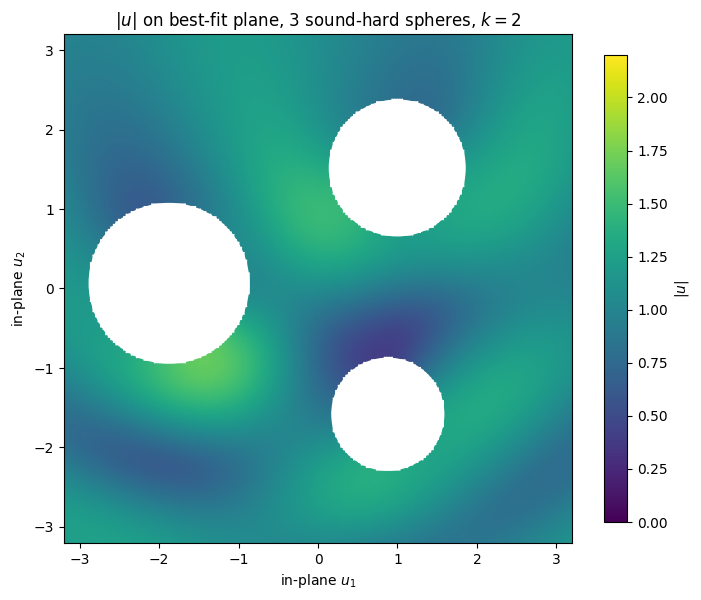

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 6.2))
pc = ax.pcolormesh(U1, U2, np.abs(Uf), cmap='viridis', shading='gouraud',
                   vmin=0.0, vmax=2.2, rasterized=True)
# sphere outlines: intersection of each sphere with the plane is a circle of
# radius sqrt(a^2 - h^2) centered at the projection of C_i
for a_i, C_i in zip(radii_f, centers_f):
    v = C_i - centroid
    h = v @ normal
    if abs(h) < a_i:
        cx, cy = v @ e1, v @ e2
        ax.add_patch(plt.Circle((cx, cy), np.sqrt(a_i**2 - h**2),
                                fill=False, color='w', lw=1.4))
ax.set_aspect('equal'); ax.set_xlabel('in-plane $u_1$'); ax.set_ylabel('in-plane $u_2$')
ax.set_title(f'$|u|$ on best-fit plane, 3 sound-hard spheres, $k={k:g}$')
fig.colorbar(pc, ax=ax, shrink=0.85, label='$|u|$')
fig.tight_layout(); plt.show()

In [11]:
print(f"total notebook runtime: {time.time() - t_start:.1f} s")

total notebook runtime: 133.1 s
